# Comparison of SciVal query works lists and OpenAlex general SFU works lists
It appears that the OpenAlex queries are not fully encapsulating the works that are available in both SciVal and OpenAlex (it appears that works are not being fully attributed to SFU through the query search). 

Here we compare the full list of SFU authors to the SciVal queries to see how much overlap there is, and then we will merge this with the OpenAlex query pulls to see if the intersecting set is the same or different. 

In [56]:
# import libraries 

import pandas as pd
import numpy as np
import json
import ast
import fuzzywuzzy
from fuzzywuzzy import fuzz
from fuzzywuzzy import process
from datetime import datetime
from tqdm import tqdm 
from collections import defaultdict
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import requests

# q1
q1_oa_raw = pd.read_csv('../cerc_results/query1.csv')
q1_sv_raw = pd.read_excel('../cerc_results/query1_SCIVAL.xlsx', sheet_name="rio results")

# q2
q2_oa_raw = pd.read_csv('../cerc_results/query2.csv')
q2_sv_raw = pd.read_excel('../cerc_results/query2_SCIVAL.xlsx', sheet_name="rio results")

# q3
q3_oa_raw = pd.read_csv('../cerc_results/query3.csv')
q3_sv_raw = pd.read_excel('../cerc_results/query3_SCIVAL.xlsx', sheet_name="rio results")

# openalex all
oa_all_pubs = pd.read_csv('../sfu_all_works.csv')
oa_all_pubs['doi'] = oa_all_pubs['doi'].str.replace('https://doi.org/', '', regex=False).str.strip().str.lower()

C:\Users\tania\AppData\Local\Temp\ipykernel_8248\561244527.py:30: DtypeWarning: Columns (21,24) have mixed types. Specify dtype option on import or set low_memory=False.
  oa_all_pubs = pd.read_csv('../sfu_all_works.csv')


In [79]:
import ast

SFU_ID = 'I18014758'

def safe_parse(val):
    """Parse a stringified list/dict back to a Python object, or return as-is if already parsed."""
    if isinstance(val, (list, dict)):
        return val
    if isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except (ValueError, SyntaxError):
            return []
    return []


def get_sfu_author_rankings(df: pd.DataFrame, sfu_id: str = SFU_ID) -> pd.DataFrame:

    records = []

    for _, row in df.iterrows():
        doi         = row.get('doi')
        authorships = safe_parse(row.get('authorships', []))
        citations   = row.get('cited_by_count', 0)

        if not isinstance(authorships, list):
            continue

        for authorship in authorships:
            if not isinstance(authorship, dict):
                continue

            institutions = safe_parse(authorship.get('institutions', []))
            is_sfu = any(
                (inst.get('id') or '').endswith(sfu_id)
                for inst in institutions
                if isinstance(inst, dict)
            )

            if not is_sfu:
                continue

            author      = authorship.get('author', {})
            author_id   = author.get('id', 'unknown')
            author_name = author.get('display_name', 'unknown')

            records.append({
                'author_id':   author_id,
                'author_name': author_name,
                'doi':         doi,
                'citations':   citations,
            })

    if not records:
        print('No SFU-affiliated authors found. Check that authorships column is parseable.')
        return pd.DataFrame()

    records_df = pd.DataFrame(records)

    rankings = (
        records_df
        .groupby(['author_id', 'author_name'], as_index=False)
        .agg(
            pub_count       =('doi',       'count'),
            total_citations =('citations', 'sum'),
            dois            =('doi',       lambda x: sorted(x.dropna().unique().tolist()))
        )
    )

    rankings['citation_rank'] = rankings['total_citations'].rank(method='min', ascending=False).astype(int)

    rankings = (
        rankings
        .sort_values('pub_count', ascending=False)
        .reset_index(drop=True)
    )

    rankings.index += 1
    rankings.index.name = 'pub_rank'

    rankings = rankings[['author_name', 'author_id', 'pub_count', 'total_citations', 'citation_rank', 'dois']]

    return rankings

In [80]:
SFU_SCOPUS_NAME = 'Simon Fraser University'

def get_sfu_author_rankings_scopus(
    df: pd.DataFrame,
    sfu_name: str = SFU_SCOPUS_NAME,
) -> pd.DataFrame:

    records = []

    for _, row in df.iterrows():
        doi               = row.get('DOI')
        author_full_names = row.get('Author full names', '')
        authors_with_affs = row.get('Authors with affiliations', '')
        author_ids_raw    = row.get('Author(s) ID', '')
        citations         = row.get('Cited by', 0)

        if not all(isinstance(x, str) for x in [author_full_names, authors_with_affs, author_ids_raw]):
            continue

        author_ids = [x.strip() for x in author_ids_raw.split(';') if x.strip()]

        name_id_pairs = []
        for entry in author_full_names.split(';'):
            entry = entry.strip()
            if not entry:
                continue
            if '(' in entry and ')' in entry:
                name    = entry[:entry.rfind('(')].strip()
                auth_id = entry[entry.rfind('(')+1 : entry.rfind(')')].strip()
            else:
                name    = entry.strip()
                idx     = len(name_id_pairs)
                auth_id = author_ids[idx] if idx < len(author_ids) else 'unknown'
            name_id_pairs.append((name, auth_id))

        name_to_id = {name: auth_id for name, auth_id in name_id_pairs}

        for entry in authors_with_affs.split(';'):
            entry = entry.strip()
            if not entry or sfu_name not in entry:
                continue

            parts = [p.strip() for p in entry.split(',')]
            if len(parts) < 2:
                continue

            author_name = f'{parts[0]}, {parts[1]}'
            author_id   = name_to_id.get(author_name, 'unknown')

            records.append({
                'author_id':   author_id,
                'author_name': author_name,
                'doi':         doi,
                'citations':   citations,
            })

    if not records:
        print('No SFU-affiliated authors found. Check that "Simon Fraser University" '
              'appears in the Authors with affiliations column.')
        return pd.DataFrame()

    records_df = pd.DataFrame(records)

    rankings = (
        records_df
        .groupby(['author_id', 'author_name'], as_index=False)
        .agg(
            pub_count       =('doi',       'count'),
            total_citations =('citations', 'sum'),
            dois            =('doi',       lambda x: sorted(x.dropna().unique().tolist()))
        )
    )

    rankings['citation_rank'] = rankings['total_citations'].rank(method='min', ascending=False).astype(int)

    rankings = (
        rankings
        .sort_values('pub_count', ascending=False)
        .reset_index(drop=True)
    )

    rankings.index += 1
    rankings.index.name = 'pub_rank'

    rankings = rankings[['author_name', 'author_id', 'pub_count', 'total_citations', 'citation_rank', 'dois']]
    
    return rankings

In [14]:
#oa_all_pubs

## Query 1

In [15]:
q1_sv_raw.columns

Index(['Authors', 'Author full names', 'Author(s) ID', 'Title', 'Year',
       'Source title', 'Volume', 'Issue', 'Art. No.', 'Page start', 'Page end',
       'Cited by', 'DOI', 'Link', 'Affiliations', 'Authors with affiliations',
       'Correspondence Address', 'Editors', 'Publisher', 'ISSN', 'ISBN',
       'CODEN', 'PubMed ID', 'Language of Original Document',
       'Abbreviated Source Title', 'Document Type', 'Publication Stage',
       'Open Access', 'Source', 'EID'],
      dtype='object')

In [16]:
q1_sv_clean = q1_sv_raw.copy()
q1_sv_clean = q1_sv_clean[['Title', 'DOI', 'Year', 'Cited by']]
q1_sv_clean

,Title,DOI,Year,Cited by
0,Planck 2018 results: V. CMB power spectra and ...,10.1051/0004-6361/201936386,2020,788
1,SuperYOLO: Super Resolution Assisted Object De...,10.1109/TGRS.2023.3258666,2023,458
2,Sapien: A simulated part-based interactive ENv...,10.1109/CVPR42600.2020.01111,2020,377
3,Habitat 2.0: Training Home Assistants to Rearr...,NaN,2021,319
4,Flood detection and susceptibility mapping usi...,10.3390/rs12020266,2020,317
...,...,...,...,...
945,Logic-based space-vector modulation for neutra...,10.1049/iet-pel.2020.0594,2020,0
946,Handling coarsened age information in the anal...,10.1186/s12874-020-01181-x,2020,0
947,Detection of Electric and Magnetic Dipole Mome...,10.1109/IEEECONF35879.2020.9330408,2020,0
948,Overcoming distrust: How state-owned enterpris...,10.4337/9781788978927.00023,2020,0


433
7253


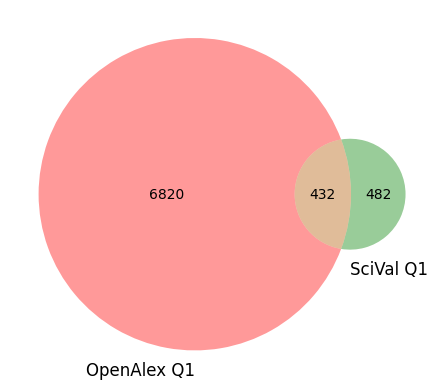

In [17]:
q1_oa_clean = q1_oa_raw
q1_oa_clean['doi'] = q1_oa_clean['doi'].str.replace('https://doi.org/', '').str.lower()

q1_sv_doi_list = q1_sv_clean['DOI'].dropna().str.strip().str.lower()

q1_oa_works_in_sv = q1_oa_clean.copy()
q1_oa_works_in_sv = q1_oa_works_in_sv[q1_oa_works_in_sv['doi'].isin(q1_sv_doi_list)].reset_index().drop(columns=['index'])

print(len(q1_oa_works_in_sv))

q1_oa_merged = q1_oa_raw.copy()
q1_oa_merged['doi'] = q1_oa_merged['doi'].str.replace('https://doi.org/', '', regex=False).str.strip().str.lower()
q1_oa_merged = pd.concat([q1_oa_merged, q1_oa_works_in_sv]).drop_duplicates(subset='doi').reset_index(drop=True)

print(len(q1_oa_merged))

q1_comp = venn2(
    [set(q1_oa_merged['doi'].dropna()),
     set(q1_sv_clean['DOI'].dropna().str.strip().str.lower())],
    set_labels=('OpenAlex Q1', 'SciVal Q1')
)

omg

## Query 2

In [18]:
q2_sv_raw.columns

Index(['Authors', 'Author full names', 'Author(s) ID', 'Title', 'Year',
       'Source title', 'Volume', 'Issue', 'Art. No.', 'Page start', 'Page end',
       'Cited by', 'DOI', 'Link', 'Affiliations', 'Authors with affiliations',
       'Correspondence Address', 'Editors', 'Publisher', 'ISSN', 'ISBN',
       'CODEN', 'PubMed ID', 'Language of Original Document',
       'Abbreviated Source Title', 'Document Type', 'Publication Stage',
       'Open Access', 'Source', 'EID'],
      dtype='object')

In [19]:
q2_sv_clean = q2_sv_raw.copy()
q2_sv_clean = q2_sv_clean[['Title', 'DOI', 'Year', 'Cited by']]
q2_sv_clean

,Title,DOI,Year,Cited by
0,Functional and versatile superhydrophobic coat...,10.1038/s41467-021-21219-y,2021,279
1,Opioid agonist treatment and risk of mortality...,10.1136/bmj.m772,2020,170
2,Optical observation of single spins in silicon,10.1038/s41586-022-04821-y,2022,142
3,"Dimensional diversity (0D, 1D, 2D, and 3D) in ...",10.1039/d3ta06953b,2024,122
4,A review of primary technologies of thin-film ...,10.1088/2631-8695/ac2353,2021,121
...,...,...,...,...
324,ITERATIVE UNCERTAINTY CALIBRATION FOR MODELING...,10.1115/DETC2022-89511,2022,0
325,Simulation of optical and mechanical performan...,10.1109/PVSC43889.2021.9518957,2021,0
326,Advanced modifications in nonnoble materials f...,10.1016/B978-0-12-823708-3.00005-5,2021,0
327,Individual Nanoflakes of Two Dimensional Mater...,10.1109/NMDC50713.2021.9677477,2021,0


253
1460


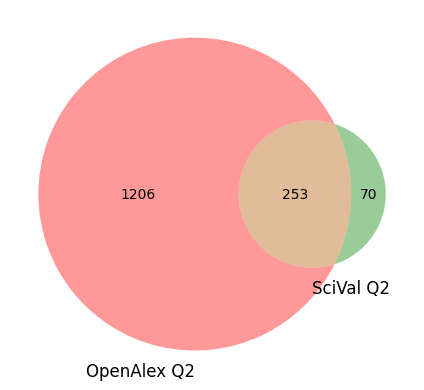

In [20]:
q2_oa_clean = q2_oa_raw
q2_oa_clean['doi'] = q2_oa_clean['doi'].str.replace('https://doi.org/', '').str.lower()

q2_sv_doi_list = q2_sv_clean['DOI'].dropna().str.strip().str.lower()

q2_oa_works_in_sv = q2_oa_clean.copy()
q2_oa_works_in_sv = q2_oa_works_in_sv[q2_oa_works_in_sv['doi'].isin(q2_sv_doi_list)].reset_index().drop(columns=['index'])

print(len(q2_oa_works_in_sv))

q2_oa_merged = q2_oa_raw.copy()
q2_oa_merged['doi'] = q2_oa_merged['doi'].str.replace('https://doi.org/', '', regex=False).str.strip().str.lower()
q2_oa_merged = pd.concat([q2_oa_merged, q2_oa_works_in_sv]).drop_duplicates(subset='doi').reset_index(drop=True)

print(len(q2_oa_merged))

q2_comp = venn2(
    [set(q2_oa_merged['doi'].dropna()),
     set(q2_sv_clean['DOI'].dropna().str.strip().str.lower())],
    set_labels=('OpenAlex Q2', 'SciVal Q2'))

In [21]:
q2_sv_doi_list = q2_sv_clean['DOI'].dropna().str.strip().str.lower()

q2_oa_works_in_sv = oa_all_pubs.copy()
q2_oa_works_in_sv = q2_oa_works_in_sv[q2_oa_works_in_sv['doi'].isin(q2_sv_doi_list)].reset_index().drop(columns=['index'])

len(q2_oa_works_in_sv)


295

In [22]:
q2_oa_merged = q2_oa_raw.copy()
q2_oa_merged['doi'] = q2_oa_merged['doi'].str.replace('https://doi.org/', '', regex=False).str.strip().str.lower()
q2_oa_merged = pd.concat([q2_oa_merged, q2_oa_works_in_sv]).drop_duplicates(subset='doi').reset_index(drop=True)

len(q2_oa_merged)

1516

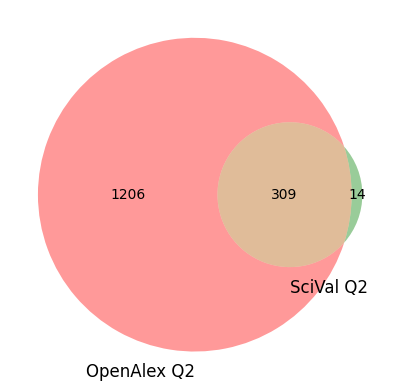

In [23]:
q2_comp = venn2(
    [set(q2_oa_merged['doi'].dropna()),
     set(q2_sv_clean['DOI'].dropna().str.strip().str.lower())],
    set_labels=('OpenAlex Q2', 'SciVal Q2')
)

## Query 3

In [24]:
q3_sv_raw.columns

Index(['Authors', 'Author full names', 'Author(s) ID', 'Title', 'Year',
       'Source title', 'Volume', 'Issue', 'Art. No.', 'Page start', 'Page end',
       'Cited by', 'DOI', 'Link', 'Affiliations', 'Authors with affiliations',
       'Correspondence Address', 'Editors', 'Publisher', 'ISSN', 'ISBN',
       'CODEN', 'PubMed ID', 'Language of Original Document',
       'Abbreviated Source Title', 'Document Type', 'Publication Stage',
       'Open Access', 'Source', 'EID'],
      dtype='object')

In [25]:
q3_sv_clean = q3_sv_raw.copy()
q3_sv_clean = q3_sv_clean[['Title', 'DOI', 'Year', 'Cited by']]
q3_sv_clean

,Title,DOI,Year,Cited by
0,The Lancet Commission on lessons for the futur...,10.1016/S0140-6736(22)01585-9,2022,601
1,Human resource management in the age of genera...,10.1111/1748-8583.12524,2023,600
2,Mobilizing Policy (In)Capacity to Fight COVID-...,10.1080/14494035.2020.1787628,2020,445
3,How right-leaning media coverage of Covid-19 f...,10.1017/S0008423920000396,2020,341
4,The Knowns and Unknowns of Policy Instrument A...,10.1177/2158244019900568,2020,297
...,...,...,...,...
763,Russia’s Space Security Policy,10.1007/978-3-030-23210-8_128,2020,0
764,Overcoming distrust: How state-owned enterpris...,10.4337/9781788978927.00023,2020,0
765,Diplomatic and corporate networks: Bridges to ...,10.4337/9781788978927.00024,2020,0
766,Lifetime trajectories of socio-economic advers...,10.1332/175795919X15717233852148,2020,0


554
2340


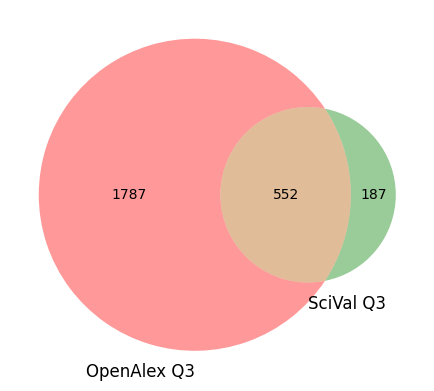

In [26]:
q3_oa_clean = q3_oa_raw
q3_oa_clean['doi'] = q3_oa_clean['doi'].str.replace('https://doi.org/', '').str.lower()

q3_sv_doi_list = q3_sv_clean['DOI'].dropna().str.strip().str.lower()

q3_oa_works_in_sv = q3_oa_clean.copy()
q3_oa_works_in_sv = q3_oa_works_in_sv[q3_oa_works_in_sv['doi'].isin(q3_sv_doi_list)].reset_index().drop(columns=['index'])

print(len(q3_oa_works_in_sv))

q3_oa_merged = q3_oa_raw.copy()
q3_oa_merged['doi'] = q3_oa_merged['doi'].str.replace('https://doi.org/', '', regex=False).str.strip().str.lower()
q3_oa_merged = pd.concat([q3_oa_merged, q3_oa_works_in_sv]).drop_duplicates(subset='doi').reset_index(drop=True)

print(len(q3_oa_merged))

q3_comp = venn2(
    [set(q3_oa_merged['doi'].dropna()),
     set(q3_sv_clean['DOI'].dropna().str.strip().str.lower())],
    set_labels=('OpenAlex Q3', 'SciVal Q3'))

In [27]:
q3_sv_doi_list = q3_sv_clean['DOI'].dropna().str.strip().str.lower()

q3_oa_works_in_sv = oa_all_pubs.copy()
q3_oa_works_in_sv = q3_oa_works_in_sv[q3_oa_works_in_sv['doi'].isin(q3_sv_doi_list)].reset_index().drop(columns=['index'])

len(q3_oa_works_in_sv)


634

In [28]:
q3_oa_merged = q3_oa_raw.copy()
q3_oa_merged['doi'] = q3_oa_merged['doi'].str.replace('https://doi.org/', '', regex=False).str.strip().str.lower()
q3_oa_merged = pd.concat([q3_oa_merged, q3_oa_works_in_sv]).drop_duplicates(subset='doi').reset_index(drop=True)

len(q3_oa_merged)

2448

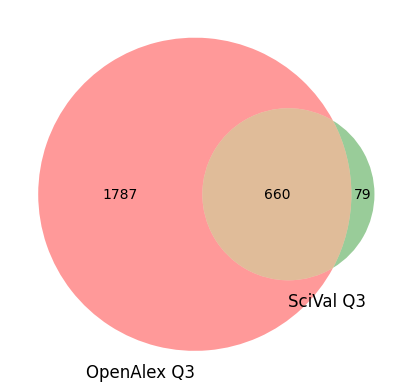

In [29]:
q3_comp = venn2(
    [set(q3_oa_merged['doi'].dropna()),
     set(q3_sv_clean['DOI'].dropna().str.strip().str.lower())],
    set_labels=('OpenAlex Q3', 'SciVal Q3')
)

as we suspected, the issue is that publications that are attributed to SFU authors in the general publication list are not being caught in the queries (i suspect it might be because of the cutoff)

## check

In [30]:
max(q1_oa_raw['institutions_distinct_count'].unique())

np.int64(1431)

In [31]:
test = q1_oa_raw[q1_oa_raw['institutions_distinct_count'] == 1403]
test

,id,doi,title,display_name,relevance_score,publication_year,publication_date,ids,language,primary_location,...,funders,has_content,content_urls,referenced_works_count,referenced_works,related_works,abstract_inverted_index,counts_by_year,updated_date,created_date
2580,https://openalex.org/W3005327280,10.1038/s41467-020-14352-7,Reconstructing evolutionary trajectories of mu...,Reconstructing evolutionary trajectories of mu...,0.814143,2020,2020-02-05,{'openalex': 'https://openalex.org/W3005327280...,en,"{'id': 'doi:10.1038/s41467-020-14352-7', 'is_o...",...,"[{'id': 'https://openalex.org/F4320309480', 'd...","{'pdf': True, 'grobid_xml': True}",{'pdf': 'https://content.openalex.org/works/W3...,50,"['https://openalex.org/W1526705543', 'https://...","['https://openalex.org/W2146397496', 'https://...","{'The': [0], 'type': [1, 98], 'and': [2, 94, 9...","[{'year': 2026, 'cited_by_count': 3}, {'year':...",2026-06-25T08:15:23.626066,2025-10-10T00:00:00


In [32]:
print(test['institutions'])

2580    []
Name: institutions, dtype: object


In [33]:
test['display_name']

2580    Reconstructing evolutionary trajectories of mu...
Name: display_name, dtype: object

for some reason, all publications have an empty array in the institutions column. I need to try some more stuff

In [34]:
# initialize the API URL
# the cursor allows us to pull multiple pages of results to get all SFU works in one call. 
# NOTE: SFU's institutional id in OpenAlex is I18014f758

url = 'https://api.openalex.org/works/w3093734695'

result = requests.get(url)

#result.json()

In [35]:
test2 = pd.DataFrame([result.json()])
test2

,id,doi,title,display_name,publication_year,publication_date,ids,language,primary_location,type,...,funders,has_content,content_urls,referenced_works_count,referenced_works,related_works,abstract_inverted_index,counts_by_year,updated_date,created_date
0,https://openalex.org/W3093734695,https://doi.org/10.1140/epjc/s10052-021-09402-3,Jet energy scale and resolution measured in pr...,Jet energy scale and resolution measured in pr...,2021,2021-08-01,{'openalex': 'https://openalex.org/W3093734695...,en,"{'id': 'doi:10.1140/epjc/s10052-021-09402-3', ...",article,...,"[{'id': 'https://openalex.org/F4320306076', 'd...","{'grobid_xml': False, 'pdf': False}",None,55,"[https://openalex.org/W580385155, https://open...","[https://openalex.org/W1610586212, https://ope...","{'Abstract': [0], 'Jet': [1], 'energy': [2, 28...","[{'year': 2026, 'cited_by_count': 9}, {'year':...",2026-07-06T08:01:05.025921,2020-10-29T00:00:00


In [36]:
oa_all_pubs['institutions']

0        []
1        []
2        []
3        []
4        []
         ..
76416    []
76417    []
76418    []
76419    []
76420    []
Name: institutions, Length: 76421, dtype: object

In [37]:
auths = pd.DataFrame(test2['authorships'][0])
auths['institutions']
auths['institution_names'] = auths['institutions'].apply(
    lambda x: [inst['display_name'] for inst in x] if x else []
)

In [38]:
auths

,author_position,author,institutions,countries,is_corresponding,raw_author_name,raw_affiliation_strings,raw_orcid,affiliations,institution_names
0,first,"{'id': 'https://openalex.org/A5100769897', 'di...","[{'id': 'https://openalex.org/I1294671590', 'd...",[FR],False,G. Aad,"[CPPM, Aix-Marseille Université, CNRS/IN2P3, M...",https://orcid.org/0000-0002-6665-4934,"[{'raw_affiliation_string': 'CPPM, Aix-Marseil...","[Centre National de la Recherche Scientifique,..."
1,middle,"{'id': 'https://openalex.org/A5007910787', 'di...","[{'id': 'https://openalex.org/I24603500', 'dis...",[US],False,B. Abbott,"[Department of Physics, University of Massachu...",https://orcid.org/0000-0002-5888-2734,[{'raw_affiliation_string': 'Department of Phy...,[University of Massachusetts Amherst]
2,middle,"{'id': 'https://openalex.org/A5088025642', 'di...","[{'id': 'https://openalex.org/I24603500', 'dis...",[US],False,D. C. Abbott,"[Department of Physics, University of Massachu...",https://orcid.org/0000-0002-7248-3203,[{'raw_affiliation_string': 'Department of Phy...,[University of Massachusetts Amherst]
3,middle,"{'id': 'https://openalex.org/A5048474802', 'di...","[{'id': 'https://openalex.org/I67311998', 'dis...",[CH],False,A. Abed Abud,"[CERN, Geneva, Switzerland]",https://orcid.org/0000-0002-2788-3822,"[{'raw_affiliation_string': 'CERN, Geneva, Swi...",[European Organization for Nuclear Research]
4,middle,"{'id': 'https://openalex.org/A5064796035', 'di...","[{'id': 'https://openalex.org/I74656192', 'dis...",[DE],False,K. Abeling,"[II. Physikalisches Institut, Georg-August-Uni...",https://orcid.org/0000-0002-1002-1652,[{'raw_affiliation_string': 'II. Physikalische...,[University of Göttingen]
...,...,...,...,...,...,...,...,...,...,...
2948,middle,"{'id': 'https://openalex.org/A5107909554', 'di...","[{'id': 'https://openalex.org/I4210148700', 'd...",[IT],False,A. Zoccoli,"[INFN Sezione di Bologna, Bologna, Italy]",https://orcid.org/0000-0002-0993-6185,[{'raw_affiliation_string': 'INFN Sezione di B...,"[Istituto Nazionale di Fisica Nucleare, Sezion..."
2949,middle,"{'id': 'https://openalex.org/A5108167659', 'di...","[{'id': 'https://openalex.org/I74656192', 'dis...",[DE],False,K. Zoch,"[II. Physikalisches Institut, Georg-August-Uni...",https://orcid.org/0000-0003-2138-6187,[{'raw_affiliation_string': 'II. Physikalische...,[University of Göttingen]
2950,middle,"{'id': 'https://openalex.org/A5102708152', 'di...","[{'id': 'https://openalex.org/I91136226', 'dis...",[GB],False,T. G. Zorbas,"[Department of Physics and Astronomy, Universi...",https://orcid.org/0000-0003-2073-4901,[{'raw_affiliation_string': 'Department of Phy...,[University of Sheffield]
2951,middle,"{'id': 'https://openalex.org/A5107890339', 'di...","[{'id': 'https://openalex.org/I24603500', 'dis...",[US],False,R. Zou,"[Department of Physics, University of Massachu...",https://orcid.org/0000-0002-0542-1264,[{'raw_affiliation_string': 'Department of Phy...,[University of Massachusetts Amherst]


In [39]:
sfu_auths = auths[auths['institution_names'].apply(lambda x: 'Simon Fraser University' in x)]
sfu_auths

,author_position,author,institutions,countries,is_corresponding,raw_author_name,raw_affiliation_strings,raw_orcid,affiliations,institution_names
136,middle,"{'id': 'https://openalex.org/A5107882155', 'di...","[{'id': 'https://openalex.org/I18014758', 'dis...",[CA],False,H. Bahrasemani,"[Department of Physics, Simon Fraser Universit...",None,[{'raw_affiliation_string': 'Department of Phy...,[Simon Fraser University]
578,middle,"{'id': 'https://openalex.org/A5039614567', 'di...","[{'id': 'https://openalex.org/I18014758', 'dis...",[CA],False,M. Danninger,"[Department of Physics, Simon Fraser Universit...",https://orcid.org/0000-0002-7807-7484,[{'raw_affiliation_string': 'Department of Phy...,[Simon Fraser University]
678,middle,"{'id': 'https://openalex.org/A5105505306', 'di...","[{'id': 'https://openalex.org/I18014758', 'dis...",[CA],False,E. Drechsler,"[Department of Physics, Simon Fraser Universit...",https://orcid.org/0000-0002-8773-7640,[{'raw_affiliation_string': 'Department of Phy...,[Simon Fraser University]
1199,middle,"{'id': 'https://openalex.org/A5105788722', 'di...","[{'id': 'https://openalex.org/I18014758', 'dis...",[CA],False,B. P. Jaeger,"[Department of Physics, Simon Fraser Universit...",https://orcid.org/0000-0002-5094-5067,[{'raw_affiliation_string': 'Department of Phy...,[Simon Fraser University]
1482,middle,"{'id': 'https://openalex.org/A5107883495', 'di...","[{'id': 'https://openalex.org/I18014758', 'dis...",[CA],False,K. Lehmann,"[Department of Physics, Simon Fraser Universit...",https://orcid.org/0000-0002-8590-8231,[{'raw_affiliation_string': 'Department of Phy...,[Simon Fraser University]
1555,middle,"{'id': 'https://openalex.org/A5077377484', 'di...","[{'id': 'https://openalex.org/I18014758', 'dis...",[CA],False,J. Llorente Merino,"[Department of Physics, Simon Fraser Universit...",https://orcid.org/0000-0003-0027-7969,[{'raw_affiliation_string': 'Department of Phy...,[Simon Fraser University]
1782,middle,"{'id': 'https://openalex.org/A5105505322', 'di...","[{'id': 'https://openalex.org/I18014758', 'dis...",[CA],False,A. Montalbano,"[Department of Physics, Simon Fraser Universit...",https://orcid.org/0000-0002-5295-432X,[{'raw_affiliation_string': 'Department of Phy...,[Simon Fraser University]
1795,middle,"{'id': 'https://openalex.org/A5044331480', 'di...","[{'id': 'https://openalex.org/I18014758', 'dis...",[CA],False,D. Mori,"[Department of Physics, Simon Fraser Universit...",https://orcid.org/0000-0002-0693-4133,[{'raw_affiliation_string': 'Department of Phy...,[Simon Fraser University]
1928,middle,"{'id': 'https://openalex.org/A5103713192', 'di...","[{'id': 'https://openalex.org/I18014758', 'dis...",[CA],False,D. C. O’Neil,"[Department of Physics, Simon Fraser Universit...",https://orcid.org/0000-0003-0325-472X,[{'raw_affiliation_string': 'Department of Phy...,[Simon Fraser University]
2063,middle,"{'id': 'https://openalex.org/A5105504768', 'di...","[{'id': 'https://openalex.org/I18014758', 'dis...",[CA],False,A. Poley,"[Department of Physics, Simon Fraser Universit...",https://orcid.org/0000-0002-4063-0408,[{'raw_affiliation_string': 'Department of Phy...,[Simon Fraser University]


## explanation

When retrieving a list of works via the API, the authorships list within each work is cut off at 100 authorships objects. When this happens, the boolean is_authors_truncated will be set to true. This affects filtering as well — if you filter works using an author ID or institution ID, you will not receive works where that institution is listed further than 100 places down on the list of authors.



## look at top auths in openalex and scival

### query 1

In [43]:
q1_oa_raw.columns

Index(['id', 'doi', 'title', 'display_name', 'relevance_score',
       'publication_year', 'publication_date', 'ids', 'language',
       'primary_location', 'type', 'indexed_in', 'open_access', 'authorships',
       'institutions', 'countries_distinct_count',
       'institutions_distinct_count', 'corresponding_author_ids',
       'corresponding_institution_ids', 'apc_list', 'apc_paid', 'fwci',
       'has_fulltext', 'cited_by_count', 'citation_normalized_percentile',
       'cited_by_percentile_year', 'biblio', 'is_retracted', 'is_paratext',
       'is_xpac', 'primary_topic', 'topics', 'keywords', 'concepts', 'mesh',
       'locations_count', 'locations', 'best_oa_location',
       'sustainable_development_goals', 'awards', 'funders', 'has_content',
       'content_urls', 'referenced_works_count', 'referenced_works',
       'related_works', 'abstract_inverted_index', 'counts_by_year',
       'updated_date', 'created_date'],
      dtype='object')

In [99]:
sfu_author_rankings = get_sfu_author_rankings(q3_oa_raw)
sfu_author_rankings.head(20)

,author_name,author_id,pub_count,total_citations,citation_rank,dois
pub_rank,,,,,,
1,Atiya Mahmood,https://openalex.org/A5027802940,26,172,20,"[https://doi.org/10.1017/s0144686x21000234, ht..."
2,Michael Howlett,https://openalex.org/A5077475073,25,964,2,"[https://doi.org/10.1002/epa2.1142, https://do..."
3,Allen E. Thornton,https://openalex.org/A5018971948,22,142,30,"[https://doi.org/10.1007/s00406-023-01664-0, h..."
4,Ahmed Al‐Rawi,https://openalex.org/A5050245548,19,148,28,"[https://doi.org/10.1007/978-3-031-61819-2_4, ..."
5,Habib Chaudhury,https://openalex.org/A5014665875,17,118,36,"[https://doi.org/10.1002/gps.5985, https://doi..."
6,Meghan Winters,https://openalex.org/A5023136423,16,280,9,"[https://doi.org/10.1016/j.aap.2020.105540, ht..."
7,Kelley Lee,https://openalex.org/A5019363540,16,580,4,"[https://doi.org/10.1007/s10903-022-01422-9, h..."
8,Andrés M. Cisneros‐Montemayor,https://openalex.org/A5041047135,14,334,8,"[https://doi.org/10.1007/978-981-19-5065-0_4, ..."
9,Rachel Weldrick,https://openalex.org/A5088991237,13,110,39,[https://doi.org/10.1080/01634372.2022.2087128...


In [103]:
sfu_author_rankings[sfu_author_rankings['author_name'].str.contains('Kaida')]

,author_name,author_id,pub_count,total_citations,citation_rank,dois
pub_rank,,,,,,
71,Angela Kaida,https://openalex.org/A5091089188,3,37,100,"[https://doi.org/10.1002/jia2.25913, https://d..."


In [104]:
sfu_author_rankings_scopus = get_sfu_author_rankings_scopus(q3_sv_raw)
sfu_author_rankings_scopus.head(20)

,author_name,author_id,pub_count,total_citations,citation_rank,dois
pub_rank,,,,,,
1,"Howlett, Michael P.",7004315057,35,1412,1,"[10.1002/epa2.1142, 10.1007/978-3-031-25689-9,..."
2,"Hayashi, Kanna",33267650300,26,289,11,"[10.1016/j.addbeh.2020.106793, 10.1016/j.druga..."
3,"Winters, Meghan L.",16235208800,23,421,5,"[10.1016/j.aap.2020.105540, 10.1016/j.healthpl..."
4,"Thornton, Allen E.",7101607212,17,217,15,"[10.1007/s00406-023-01664-0, 10.1016/S2468-266..."
5,"Cisneros-Montemayor, Andrés Miguel",36094057100,17,322,8,"[10.1007/978-981-19-5065-0_4, 10.1007/s11160-0..."
6,"DeBeck, Kora",16063277500,14,132,34,"[10.1016/j.drugalcdep.2021.108829, 10.1016/j.d..."
7,"Lee, Kelley",55540777300,13,378,6,"[10.1007/s10903-022-01422-9, 10.1016/S0140-673..."
8,"Goldenberg, Shira M.",35310255700,12,256,12,"[10.1007/978-3-030-64171-9, 10.1007/978-3-030-..."
9,"Somers, Julian M.",8071300500,12,120,38,"[10.1007/s10488-020-01008-3, 10.1007/s11524-02..."


In [108]:
sfu_author_rankings_scopus[sfu_author_rankings_scopus['author_name'].str.contains('Kishore')]

,author_name,author_id,pub_count,total_citations,citation_rank,dois
pub_rank,,,,,,
23,"Seetharaman, Kishore",57214320425,6,101,43,"[10.1080/21650020.2023.2296891, 10.1093/geront..."
